# **AnchorMiner — MHC-I Anchor Position Predictor**

Anchor residues are amino acids within a peptide that form direct contacts with the MHC-I binding groove. They serve a structural docking function rather than defining T cell recognition, making their identification useful for immunogenicity modeling, epitope masking, and feature engineering in machine learning pipelines. AnchorMiner is a tool designed to identify anchor residues for a given peptide and its associated **MHC I** molecule. Below, we provide a tutorial on how to use this tool.

# **AnchorMiner Approach**

## Overview

AnchorMiner identifies MHC-I anchor positions using allele-specific and
length-specific Position Probability Matrices (PPMs) built from NetMHCpan-4.2
predictions on a 1.500,000-peptide background sample drawn from the human
SwissProt proteome. For each HLA allele and peptide length, strong binders
(%Rank < 0.75) are used to construct a PPM with Bayesian background
pseudocounts normalized against human proteome amino acid frequencies.

## Anchor Identification Algorithm

Anchor positions are identified using two sequential thresholds:

### 1. Position-level Threshold
KL divergence between the PPM position distribution and background proteome
frequencies. Positions exceeding this threshold show statistically significant
amino acid selection pressure and are candidate anchors.

### 2. Residue-level Threshold
For a candidate anchor position, AnchorMiner identifies the biochemical cluster
of the peptide's amino acid at that position (e.g. aliphatic, basic, aromatic)
and computes the cumulative PPM frequency of that cluster. If the cumulative
frequency exceeds the cluster threshold )0.3), the residue is confirmed
as an anchor. 

### Canonical vs Non-canonical Anchors
- **Canonical anchors** (P2 and PΩ) follow classical MHC-I binding logic
- **Non-canonical anchors** at other positions are detected automatically
without hardcoded rules, capturing allele-specific binding differences

## Output

`AnchorMiner` returns a dictionary with the following keys:

| Key | Description |
|-----|-------------|
| `'coords'` | List of anchor position indices (0-indexed) |
| `'verbose'` | List of dicts per anchor position: position index, KL divergence, canonical/non-canonical classification, biochemical cluster, cumulative cluster frequency, current amino acid, anchor result |
| `'KL'` | KL divergence plot (only if `viz=True`) |
| `'logo'` | Sequence logo with anchor positions highlighted (only if `viz=True`) |

# **Example Workflow**

In [1]:
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.dirname(os.getcwd()))
from src import AnchorMiner
from src.predict_anchors import predict_anchors
import tqdm
import matplotlib.pyplot as plt


### Single inputs, `viz` = False

In [4]:
peptides = ['AAGIGILTV', 'AALDSRKNYNW', 'AAQFNASPV', 'AASTLLYATV']
hlas = ['HLA-A02:02', 'HLA-B57:01', 'HLA-A02:01', 'HLA-A02:01']
results = []

for i in range(len(peptides)):
    results.append(predict_anchors(peptides[i], hlas[i], 0.5, False))


for i in range(len(results)):
    print('=' * 80)
    print(f'Epitope: {peptides[i]}, {hlas[i]}')
    print('- - '*20)
    print('Anchor coordinates:', results[i]['coords'])
    print('Per-residue data:')
    for position in results[i]['verbose']:
        for info in position:
            print(info,':', position[info])


Epitope: AAGIGILTV, HLA-A02:02
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Anchor coordinates: [1, 8]
Per-residue data:
position : 1
kl : 1.9211
type : canonical
cluster : aliphatic(['I', 'L', 'V', 'A'])
cumulative cluster frequency : 0.829940702761955
current_aa : A
result : anchor
position : 8
kl : 1.7122
type : canonical
cluster : aliphatic(['I', 'L', 'V', 'A'])
cumulative cluster frequency : 0.9278398585722599
current_aa : V
result : anchor
Epitope: AALDSRKNYNW, HLA-B57:01
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Anchor coordinates: [1, 10]
Per-residue data:
position : 1
kl : 0.6946
type : canonical
cluster : aliphatic(['I', 'L', 'V', 'A'])
cumulative cluster frequency : 0.30955061684509627
current_aa : A
result : anchor
position : 10
kl : 3.7143
type : canonical
cluster : tryptophane(['W'])
cumulative cluster frequency : 0.5610914838326967
current_aa : W
result : anchor
Epitope: AAQFNASPV, HLA-A02:01
- - 

### Single input, `viz` = True

Epitope: AAGIGILTV, HLA-A02:02
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Anchor coordinates: [1, 8]
Per-residue data:
position : 1
kl : 1.9211
type : canonical
cluster : aliphatic(['I', 'L', 'V', 'A'])
cumulative cluster frequency : 0.829940702761955
current_aa : A
result : anchor
position : 8
kl : 1.7122
type : canonical
cluster : aliphatic(['I', 'L', 'V', 'A'])
cumulative cluster frequency : 0.9278398585722599
current_aa : V
result : anchor


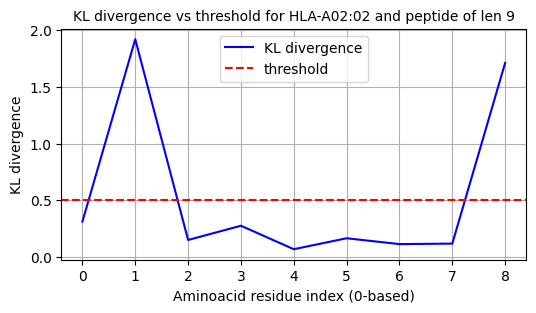

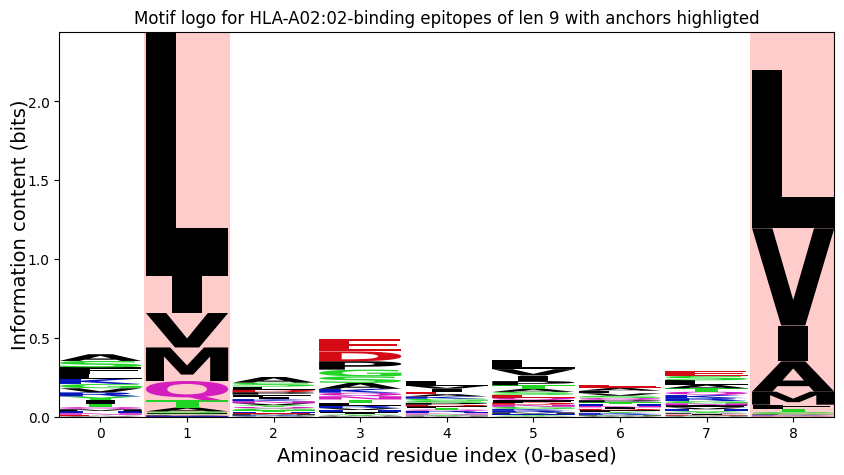

In [5]:
peptides = ['AAGIGILTV']
hlas = ['HLA-A02:02']
results = []

for i in range(len(peptides)):
    results.append(predict_anchors(peptides[i], hlas[i], 0.5, True))


for i in range(len(results)):
    print('=' * 80)
    print(f'Epitope: {peptides[i]}, {hlas[i]}')
    print('- - '*20)
    print('Anchor coordinates:', results[i]['coords'])
    print('Per-residue data:')
    for position in results[i]['verbose']:
        for info in position:
            print(info,':', position[info])


### Anchors masking with AnchorMiner

In [2]:
from src.standartize_hlas import normalize_allele

In [3]:
df = pd.read_csv('../datasets/epitope_HLA_data.tsv', sep = '\t')[['Peptide', 'HLA_Allele']]
df.drop_duplicates(subset=['Peptide'], keep='first', inplace=True)

HLA_Alleles_standartized = [normalize_allele(i) for i in df['HLA_Allele'].tolist()]
df['HLA_Allele'] = HLA_Alleles_standartized

df = df.drop(df[df['Peptide'].isna()].index)
df = df.drop(df[df['HLA_Allele'].isna()].index)



anchors = []
anchors_masked = []
not_anchors_masked = []

df = df[:100]
for index,row in tqdm.tqdm(df.iterrows(), total = len(df)):
   try:
      anchors.append(predict_anchors(row['Peptide'], row['HLA_Allele'], 0.5, False)['coords'])
      anchors_masked.append(''.join('X' if i in anchors[-1] else char for i, char in enumerate(row['Peptide'])))
      not_anchors_masked.append(''.join('X' if i not in anchors[-1] else char for i, char in enumerate(row['Peptide'])))

   except:

      #If we want to label unknown HLA alleles as NA
      #anchors.append(pd.NA)
      #anchors_masked.append(pd.NA)
      #not_anchors_masked.append(pd.NA)

      #If we want to keep P2 and Pomega for unknown HLAs

      anchors.append([1, len(row['Peptide'])-1])
      anchors_masked.append(''.join('X' if i in anchors[-1] else char for i, char in enumerate(row['Peptide'])))
      not_anchors_masked.append(''.join('X' if i not in anchors[-1] else char for i, char in enumerate(row['Peptide'])))





df['anchors'] = anchors
df['anchors_masked'] = anchors_masked
df['not_anchors_masked'] = not_anchors_masked
    
display(df)

100%|██████████| 100/100 [00:00<00:00, 422.16it/s]


,Peptide,HLA_Allele,anchors,anchors_masked,not_anchors_masked
1,AAAAAAAAK,HLA-A03:01,"[1, 8]",AXAAAAAAX,XAXXXXXXK
3,AAAAAAAAL,HLA-B07:01,"[1, 8]",AXAAAAAAX,XAXXXXXXL
4,AAAAAAAALY,HLA-A29:02,"[1, 9]",AXAAAAAALX,XAXXXXXXXY
5,AAAAAIFVI,HLA-B51:01,"[1, 8]",AXAAAIFVX,XAXXXXXXI
6,AAAAGWQTL,HLA-A02:01,"[1, 8]",AXAAGWQTX,XAXXXXXXL
...,...,...,...,...,...
185,AEAEKQLGA,HLA-B50:01,"[1, 8]",AXAEKQLGX,XEXXXXXXA
186,AEAEKQLQQA,HLA-B50:01,"[1, 9]",AXAEKQLQQX,XEXXXXXXXA
187,AEAERAAEA,HLA-B50:01,"[1, 8]",AXAERAAEX,XEXXXXXXA
188,AEAERAVVL,HLA-B50:01,"[1, 8]",AXAERAVVX,XEXXXXXXL
